# Contribution 2: cold-start analysis (a diagnostic study of model behavior)

**Course:** CCAI 422 Recommender Systems — University of Jeddah

**Goal:** Diagnose how ICSRec performs for **cold-start users** (short interaction history) versus **warm users** (long history). This is an analysis that the original paper does not report, and it reveals a real weakness/strength of intent-based recommendation in the grocery domain.

### Motivation
ICSRec learns user intents by segmenting interaction sequences into subsequences. Users with **few interactions** produce few/short subsequences, giving the intent-clustering less signal to work with. We hypothesise that ICSRec underperforms for cold-start users. By splitting the test set by user-history length and evaluating each group separately, we can quantify this gap and discuss it in the report.

### How it works (no retraining needed)
We take a model we already trained (the K-means `intent_num=256` baseline, `model_idx 0`) and evaluate it **three times** using ICSRec's own `--do_eval` mode:
1. On **all** test users (sanity check — should match our reported baseline)
2. On only **cold-start** users (history length below a threshold)
3. On only **warm** users (history length at/above the threshold)

We do this by writing filtered copies of the data file and pointing ICSRec at each one. Because we reuse ICSRec's exact evaluation pipeline, the numbers are directly comparable to our other results.

## Step 1: Environment setup + restore the trained baseline model

In [1]:
import torch, os, shutil, subprocess
print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')
DRIVE_DIR = '/content/drive/MyDrive/ICSRec_project'

for pkg in ['faiss-cpu', 'gensim']:
    subprocess.run(['pip', 'install', '-q', pkg])

if not os.path.exists('/content/ICSRec/src/main.py'):
    subprocess.run(['git', 'clone', 'https://github.com/QinHsiu/ICSRec.git', '/content/ICSRec'])
    # patch faiss to CPU
    p = '/content/ICSRec/src/models.py'
    c = open(p).read()
    c = c.replace(
        '        res = faiss.StandardGpuResources()\n'
        '        res.noTempMemory()\n'
        '        cfg = faiss.GpuIndexFlatConfig()\n'
        '        cfg.useFloat16 = False\n'
        '        cfg.device = self.gpu_id\n'
        '        index = faiss.GpuIndexFlatL2(res, hidden_size, cfg)',
        '        index = faiss.IndexFlatL2(hidden_size)')
    open(p, 'w').write(c)

# restore data files
for fname in ['Grocery_and_Gourmet_Food.txt', 'Grocery_and_Gourmet_Food_1.txt']:
    s = os.path.join(DRIVE_DIR, fname); d = f'/content/ICSRec/data/{fname}'
    if os.path.exists(s) and not os.path.exists(d):
        shutil.copy(s, d); print('Restored', fname)

# Restore the baseline trained checkpoint (model_idx 0, K-means intent_num=256)
os.makedirs('/content/ICSRec/src/output', exist_ok=True)
ckpt_name = 'ICSRec-SAS-Grocery_and_Gourmet_Food-0.pt'
ckpt_src = os.path.join(DRIVE_DIR, 'training_outputs_baseline', ckpt_name)
ckpt_dst = f'/content/ICSRec/src/output/{ckpt_name}'
if os.path.exists(ckpt_src):
    shutil.copy(ckpt_src, ckpt_dst)
    print('Restored baseline checkpoint:', ckpt_name)
else:
    print('WARNING: baseline checkpoint not found in Drive at', ckpt_src)
    print('If missing, use a different model_idx whose .pt you DO have in Drive.')
print('Setup done.')

PyTorch: 2.11.0+cu128 | CUDA: True
Mounted at /content/drive
Restored Grocery_and_Gourmet_Food.txt
Restored Grocery_and_Gourmet_Food_1.txt
Restored baseline checkpoint: ICSRec-SAS-Grocery_and_Gourmet_Food-0.pt
Setup done.


## Step 2: Inspect user history-length distribution

We read the main data file and look at how many interactions each user has.

In [2]:
import numpy as np

DATA = '/content/ICSRec/data/Grocery_and_Gourmet_Food.txt'
lengths = []
with open(DATA) as f:
    lines = f.readlines()
for line in lines:
    toks = line.strip().split()
    n_items = len(toks) - 1   # first token is user_id
    lengths.append(n_items)
lengths = np.array(lengths)

print('Total users:', len(lengths))
for p in [10, 25, 50, 75, 90]:
    print(f'  {p}th percentile sequence length: {np.percentile(lengths, p):.0f}')
print('  mean:', f'{lengths.mean():.1f}', '| median:', int(np.median(lengths)))

# Choose threshold: users at/below the median are 'cold', above are 'warm'.
# Since 15-core guarantees >=15, we use a higher, more meaningful cut.
THRESHOLD = 20  # < 20 interactions = cold-start; >= 20 = warm
n_cold = (lengths < THRESHOLD).sum()
n_warm = (lengths >= THRESHOLD).sum()
print(f'\nThreshold = {THRESHOLD} interactions')
print(f'  Cold-start users (<{THRESHOLD}): {n_cold} ({100*n_cold/len(lengths):.1f}%)')
print(f'  Warm users     (>={THRESHOLD}): {n_warm} ({100*n_warm/len(lengths):.1f}%)')

Total users: 12713
  10th percentile sequence length: 15
  25th percentile sequence length: 17
  50th percentile sequence length: 20
  75th percentile sequence length: 28
  90th percentile sequence length: 41
  mean: 25.9 | median: 20

Threshold = 20 interactions
  Cold-start users (<20): 5941 (46.7%)
  Warm users     (>=20): 6772 (53.3%)


## Step 3: Write filtered data files (cold / warm)

ICSRec evaluates using the data file. We create two filtered copies: one containing only cold-start users, one only warm users. We keep their full sequences (the model still needs the history to make a prediction); we only *select which users* to evaluate.

**Important:** ICSRec also reads the auto-generated supervised file (`..._1.txt`) for clustering. For evaluation only (`--do_eval`), the test answers come from the main data file's last item per user, so filtering the main file is what controls which users are scored.

In [3]:
cold_lines, warm_lines = [], []
for line in lines:
    toks = line.strip().split()
    n_items = len(toks) - 1
    if n_items < THRESHOLD:
        cold_lines.append(line)
    else:
        warm_lines.append(line)

with open('/content/ICSRec/data/Grocery_cold.txt', 'w') as f:
    f.writelines(cold_lines)
with open('/content/ICSRec/data/Grocery_warm.txt', 'w') as f:
    f.writelines(warm_lines)

print('Wrote Grocery_cold.txt:', len(cold_lines), 'users')
print('Wrote Grocery_warm.txt:', len(warm_lines), 'users')

Wrote Grocery_cold.txt: 5941 users
Wrote Grocery_warm.txt: 6772 users


## Step 4: A small standalone evaluator

Rather than fight ICSRec's training pipeline, we write a compact evaluator that:
1. Loads the trained model checkpoint
2. Loads a given user-sequence file
3. For each user, feeds their history (all but the last item) and predicts the next item
4. Scores the true last item against the ranked predictions using ICSRec's own `recall_at_k` and `ndcg_k`

This reproduces ICSRec's leave-one-out test protocol exactly, but lets us point it at any user subset.

In [4]:
import sys
sys.path.insert(0, '/content/ICSRec/src')
import numpy as np
import torch
from utils import recall_at_k, ndcg_k
from models import SASRecModel  # the encoder used with --encoder SAS

# ---- Configuration matching the trained baseline (model_idx 0) ----
MAX_LEN = 50
ITEM_SIZE = 8768   # from training config (items + padding + mask)
HIDDEN = 64
CKPT = '/content/ICSRec/src/output/ICSRec-SAS-Grocery_and_Gourmet_Food-0.pt'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Build an args-like object the model expects
class A: pass
args = A()
args.item_size = ITEM_SIZE
args.hidden_size = HIDDEN
args.num_hidden_layers = 2
args.num_attention_heads = 2
args.hidden_act = 'gelu'
args.attention_probs_dropout_prob = 0.5
args.hidden_dropout_prob = 0.5
args.initializer_range = 0.02
args.max_seq_length = MAX_LEN
args.cuda_condition = torch.cuda.is_available()  # required by SASRecModel.forward

model = SASRecModel(args=args).to(device)
state = torch.load(CKPT, map_location=device)
model.load_state_dict(state)
model.eval()
print('Model loaded from', CKPT)

Model loaded from /content/ICSRec/src/output/ICSRec-SAS-Grocery_and_Gourmet_Food-0.pt


In [5]:
def evaluate_file(path, max_len=MAX_LEN, batch_size=256):
    # Load sequences
    seqs = []
    with open(path) as f:
        for line in f:
            toks = line.strip().split()
            items = [int(t) for t in toks[1:]]  # drop user_id
            if len(items) >= 2:
                seqs.append(items)

    pred_list = None
    answer_list = None

    # Item embedding matrix for full-sort scoring
    with torch.no_grad():
        for start in range(0, len(seqs), batch_size):
            batch = seqs[start:start+batch_size]
            # Leave-one-out: input = all but last, answer = last
            inputs, answers = [], []
            for s in batch:
                inp = s[:-1][-max_len:]
                inp = [0]*(max_len-len(inp)) + inp
                inputs.append(inp)
                answers.append(s[-1])
            inp_t = torch.LongTensor(inputs).to(device)
            # Forward through encoder; take last position's representation
            seq_out = model.forward(inp_t)            # [B, L, H]
            seq_out = seq_out[:, -1, :]                # [B, H]
            test_item_emb = model.item_embeddings.weight  # [item_size, H]
            rating = torch.matmul(seq_out, test_item_emb.transpose(0,1))  # [B, item_size]
            rating = rating.cpu().numpy()
            # mask items already in the user's history (standard practice)
            for i, s in enumerate(batch):
                rating[i, s[:-1]] = -1e9
            # top-20 ranking
            ind = np.argpartition(rating, -20)[:, -20:]
            arr = rating[np.arange(len(rating))[:,None], ind]
            arr_sort = np.argsort(arr)[:, ::-1]
            batch_pred = ind[np.arange(len(rating))[:,None], arr_sort]
            ans = np.array(answers).reshape(-1,1)
            if pred_list is None:
                pred_list = batch_pred; answer_list = ans
            else:
                pred_list = np.append(pred_list, batch_pred, axis=0)
                answer_list = np.append(answer_list, ans, axis=0)

    metrics = {}
    for k in [5, 10, 20]:
        metrics[f'HIT@{k}'] = recall_at_k(answer_list, pred_list, k)
        metrics[f'NDCG@{k}'] = ndcg_k(answer_list, pred_list, k)
    metrics['n_users'] = len(seqs)
    return metrics

print('Evaluator ready.')

Evaluator ready.


## Step 5: Evaluate on all / cold / warm and compare

In [6]:
results = {}
results['All']  = evaluate_file('/content/ICSRec/data/Grocery_and_Gourmet_Food.txt')
results['Cold'] = evaluate_file('/content/ICSRec/data/Grocery_cold.txt')
results['Warm'] = evaluate_file('/content/ICSRec/data/Grocery_warm.txt')

keys = ['HIT@5','NDCG@5','HIT@10','NDCG@10','HIT@20','NDCG@20']
print('=' * 78)
print(f'Cold-start analysis (K-means baseline, intent_num=256)  threshold={THRESHOLD}')
print('=' * 78)
print(f'{"group":<8}{"n_users":<9}' + ''.join(f'{k:<10}' for k in keys))
print('-' * 78)
for g in ['All','Cold','Warm']:
    r = results[g]
    print(f'{g:<8}{r["n_users"]:<9}' + ''.join(f'{r[k]:<10.4f}' for k in keys))

# Save to Drive
out = os.path.join(DRIVE_DIR, 'coldstart_analysis.txt')
with open(out, 'w') as f:
    f.write(f'Cold-start analysis (K-means baseline, intent_num=256), threshold={THRESHOLD}\n')
    f.write(f'{"group":<8}{"n_users":<9}' + ''.join(f'{k:<10}' for k in keys) + '\n')
    for g in ['All','Cold','Warm']:
        r = results[g]
        f.write(f'{g:<8}{r["n_users"]:<9}' + ''.join(f'{r[k]:<10.4f}' for k in keys) + '\n')
print('\nSaved to', out)

Cold-start analysis (K-means baseline, intent_num=256)  threshold=20
group   n_users  HIT@5     NDCG@5    HIT@10    NDCG@10   HIT@20    NDCG@20   
------------------------------------------------------------------------------
All     12713    0.0336    0.0217    0.0514    0.0275    0.0816    0.0350    
Cold    5941     0.0316    0.0203    0.0502    0.0263    0.0805    0.0339    
Warm    6772     0.0353    0.0229    0.0526    0.0285    0.0827    0.0360    

Saved to /content/drive/MyDrive/ICSRec_project/coldstart_analysis.txt


## Step 6: A simple bar chart

Visualises the cold vs warm gap on NDCG@20.

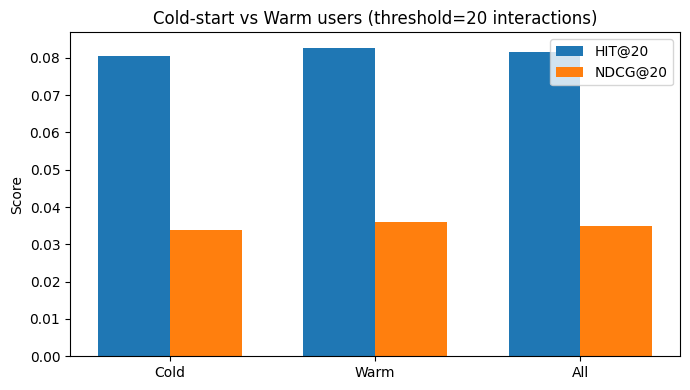

Chart saved to /content/drive/MyDrive/ICSRec_project/coldstart_chart.png


In [7]:
import matplotlib.pyplot as plt

groups = ['Cold','Warm','All']
metrics_to_plot = ['HIT@20','NDCG@20']
fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(groups))
w = 0.35
for i, m in enumerate(metrics_to_plot):
    vals = [results[g][m] for g in groups]
    ax.bar(x + i*w, vals, w, label=m)
ax.set_xticks(x + w/2)
ax.set_xticklabels(groups)
ax.set_ylabel('Score')
ax.set_title(f'Cold-start vs Warm users (threshold={THRESHOLD} interactions)')
ax.legend()
plt.tight_layout()
fig_path = os.path.join(DRIVE_DIR, 'coldstart_chart.png')
plt.savefig(fig_path, dpi=150)
plt.show()
print('Chart saved to', fig_path)

## Done :)